In [4]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [5]:
r = np.full((20, 1000),fill_value=np.nan)

In [6]:
df = pd.read_csv('ratings_long.csv')

In [7]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [8]:
r

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

## ÇÖZÜM

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('ratings_long.csv')
df.head(11)

,userId,movieId,rating
0,0,16,5
1,0,72,5
2,0,86,5
3,0,259,1
4,0,319,4
5,0,521,4
6,0,534,2
7,0,671,1
8,0,673,2
9,0,739,3


In [13]:
mask = ~np.isnan(r) #sadece gözlenen hucreler true

n_observed = mask.sum()
print("Gözlenen (NaN olmayan) rating sayisi:", n_observed)
print("Doluluk orani: %.2f%%" % (100 * n_observed / r.size))

Gözlenen (NaN olmayan) rating sayisi: 200
Doluluk orani: 1.00%


In [15]:
r_filled = np.nan_to_num(r, nan=0.0)
r_filled
#nanlar 0 ıle doldur

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 4., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [18]:
np.random.seed(42)
U = np.random.normal(0, 0.1, size=(20, 4))   # 20 x 4
V = np.random.normal(0, 0.1, size=(4, 1000))  # 4 x 1000

print("U shape:", U.shape, "| V shape:", V.shape)

U shape: (20, 4) | V shape: (4, 1000)


Loss Fonskaiyonu

In [19]:
def loss_fn(R_filled, mask, U, V, lamb):

    pred = U @ V
    error = (pred - R_filled) * mask          # gözlenmeyen hücreler sifirl
    n_obs = mask.sum()
    mse = np.sum(error ** 2) / n_obs          # ortalama sadece gözlenenler üzerinden yap
    reg = lamb * (np.sum(U ** 2) + np.sum(V ** 2))
    return mse + reg

Gradient Descent ve Türevler

In [21]:
def train_matrix_factorization(R_filled, mask, k=4, lr=0.01, lamb=0.01,
                               n_epoch=5000, early_stop=1e-4, verbose_every=500):
   
    np.random.seed(42)
    U = np.random.normal(0, 0.1, size=(R_filled.shape[0], k))
    V = np.random.normal(0, 0.1, size=(k, R_filled.shape[1]))

    n_obs = mask.sum()
    losses = []

    for epoch in range(n_epoch):
        pred = U @ V
        error = (pred - R_filled) * mask         

        loss = loss_fn(R_filled, mask, U, V, lamb)
        losses.append(loss)

      
        grad_U = (2 / n_obs) * (error @ V.T) + 2 * lamb * U
        grad_V = (2 / n_obs) * (U.T @ error) + 2 * lamb * V

        grad_norm = np.sqrt(np.sum(grad_U ** 2) + np.sum(grad_V ** 2)) #gradyan normu;büyükse hala öğreniyor

        if epoch % verbose_every == 0:
            print(f"epoch {epoch:5d} | loss {loss:.6f} | grad_norm {grad_norm:.6f}")

       
        if grad_norm < early_stop:
            print(f"Erken durma (epoch {epoch}): grad_norm {grad_norm:.6f} < {early_stop}") #model artık ogrenmıyorsa durur
            break

      
        U -= lr * grad_U
        V -= lr * grad_V

    print(f"Bitti. Son loss: {losses[-1]:.6f}")
    return U, V, losses

In [23]:
# Modeli egitimi
k = 4
lr = 0.01          # deger buyukse sapıtabılır.kucukse yavaş öğrenir
lamb = 0.01        
n_epoch = 5000

U, V, losses = train_matrix_factorization(
    r_filled, mask, k=k, lr=lr, lamb=lamb, n_epoch=n_epoch, early_stop=1e-4
)

epoch     0 | loss 11.478992 | grad_norm 0.190976
epoch   500 | loss 11.312061 | grad_norm 0.186267
epoch  1000 | loss 11.086223 | grad_norm 0.247758
epoch  1500 | loss 10.624122 | grad_norm 0.363219
epoch  2000 | loss 9.714436 | grad_norm 0.480277
epoch  2500 | loss 8.398633 | grad_norm 0.533375
epoch  3000 | loss 6.981222 | grad_norm 0.521822
epoch  3500 | loss 5.760346 | grad_norm 0.457135
epoch  4000 | loss 4.927274 | grad_norm 0.354389
epoch  4500 | loss 4.452311 | grad_norm 0.266022
Bitti. Son loss: 4.168800


In [ ]:
epoch 5000 den önce kesti çünkü

In [24]:
print("Final loss:", losses[-1])

prediction_matrix = U @ V #tahmin

prediction_matrix_clipped = np.clip(prediction_matrix, 1, 5) #tahmınlerı verı setındekı aralıga cekmek
prediction_matrix_clipped

Final loss: 4.168800385556416


array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 3.45364331,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       ...,
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]])

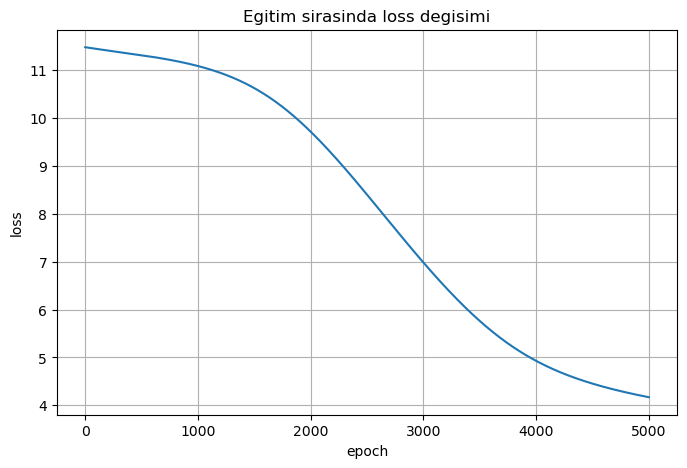

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(losses)), losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Egitim sirasinda loss degisimi')
plt.grid(True)
plt.show()

In [28]:
sample = df.head(11).copy()
sample['predicted_rating'] = [
    prediction_matrix_clipped[int(row.userId), int(row.movieId)]
    for row in sample.itertuples()
]
sample = sample.rename(columns={'rating': 'actual_rating'})
sample[['userId', 'movieId', 'actual_rating', 'predicted_rating']]

,userId,movieId,actual_rating,predicted_rating
0,0,16,5,4.527777
1,0,72,5,3.932472
2,0,86,5,3.944396
3,0,259,1,1.000000
4,0,319,4,3.190380
5,0,521,4,3.111825
6,0,534,2,1.307897
7,0,671,1,1.000000
8,0,673,2,1.627666
9,0,739,3,1.402606


SONUÇ

-seyrek matris düşük boyutlu iki matrisle yaklaşıklandı.

-sadece gözlenen matrisler ratingler üstünden mse olarak hesaplandı;gözlenmeyen degerler mask ıle hesaba katılmadı.

-l2 reg ile overfiting azaltıldı.

-elle türetilmiş gradyanlarla gradient descent uygulandı ve gradyan normuna göre erken durma eklendi.
